In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import shutil
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Preprocessing

In [3]:
datagen = ImageDataGenerator(
    rescale=1./255,         
    validation_split=0.2    
)

base_dir = 'C:\\Users\\pidik\\Downloads\\lung_image_sets'

# train = 80
train_generator = datagen.flow_from_directory(
    base_dir,              
    target_size=(150, 150), 
    batch_size=32,
    class_mode='categorical',
    subset='training'       # Training data (80%)
)

# test - 20
validation_generator = datagen.flow_from_directory(
    base_dir,              # Use the same base directory for validation
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'     # Validation data (20%)
)

Found 12000 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.


CNN

In [4]:
model = tf.keras.models.Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax') 
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

C:\Users\pidik\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=2
)

Epoch 1/2


C:\Users\pidik\anaconda3\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


375/375 ━━━━━━━━━━━━━━━━━━━━ 674s 2s/step - accuracy: 0.7543 - loss: 0.5264 - val_accuracy: 0.8800 - val_loss: 0.2579
Epoch 2/2


C:\Users\pidik\anaconda3\lib\contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.8750 - val_loss: 0.1916


In [6]:
train_dir = "C:\\Users\\pidik\\Downloads\\train_lung"
test_dir = "C:\\Users\\pidik\\Downloads\\test_lung"

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,  
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc * 100:.2f}%")

Found 3000 images belonging to 3 classes.
94/94 ━━━━━━━━━━━━━━━━━━━━ 75s 792ms/step - accuracy: 0.8775 - loss: 0.2590
Test accuracy: 88.23%


ResNet50

In [7]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

for layer in base_model.layers:
    layer.trainable = False

transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),  
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  
])

# Compile the model
transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
transfer_history = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=2
)

# Evaluate the model
val_loss, val_acc = transfer_model.evaluate(validation_generator)
print(f"Validation accuracy with ResNet50: {val_acc * 100:.2f}%")

Epoch 1/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 835s 2s/step - accuracy: 0.3851 - loss: 1.1262 - val_accuracy: 0.5150 - val_loss: 1.0109
Epoch 2/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 696s 2s/step - accuracy: 0.4853 - loss: 1.0029 - val_accuracy: 0.5367 - val_loss: 0.9474
94/94 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.5423 - loss: 0.9461
Validation accuracy with ResNet50: 53.67%


ANN

In [8]:
import os
base_dir = 'C:\\Users\\pidik\\Downloads\\lung_image_sets'
classes = os.listdir(base_dir)
print("Available directories in the dataset:", classes)

Available directories in the dataset: ['lung_aca', 'lung_n', 'lung_scc']


In [9]:
# Define ANN model
model_ann = Sequential([
    Flatten(input_shape=(150, 150, 3)), 
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')     
])

C:\Users\pidik\anaconda3\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# Compile 
model_ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [11]:
# Train 
model_ann.fit(train_generator, epochs=2, validation_data=validation_generator)

Epoch 1/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 400s 1s/step - accuracy: 0.6021 - loss: 6.0194 - val_accuracy: 0.6850 - val_loss: 1.8544
Epoch 2/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 377s 993ms/step - accuracy: 0.7450 - loss: 0.8659 - val_accuracy: 0.6557 - val_loss: 1.0646


In [12]:
# Evaluate 
loss, accuracy = model_ann.evaluate(validation_generator)
print(f"ANN Validation Accuracy: {accuracy * 100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 84s 889ms/step - accuracy: 0.6544 - loss: 1.1007
ANN Validation Accuracy: 65.57%


RNN

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Reshape
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [14]:
datagen = ImageDataGenerator(
    rescale=1./255,        
    validation_split=0.2    
)

In [15]:
# RNN model
model_rnn = Sequential([
    Reshape((150, 150 * 3), input_shape=(150, 150, 3)),  
    SimpleRNN(128, activation='relu', return_sequences=False), 
    Dense(64, activation='relu'),
    Dense(3, activation='softmax') 
])

C:\Users\pidik\anaconda3\lib\site-packages\keras\src\layers\reshaping\reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
# Compile 
model_rnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
# Train 
model_rnn.fit(train_generator, epochs=2, validation_data=validation_generator)

Epoch 1/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 6032s 16s/step - accuracy: 0.6430 - loss: 0.6595 - val_accuracy: 0.7330 - val_loss: 0.5093
Epoch 2/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 312s 819ms/step - accuracy: 0.7177 - loss: 0.5279 - val_accuracy: 0.7303 - val_loss: 0.5128


In [18]:
# Evaluate 
loss, accuracy = model_rnn.evaluate(validation_generator)
print(f"RNN Validation Accuracy: {accuracy * 100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 63s 665ms/step - accuracy: 0.7237 - loss: 0.5150
RNN Validation Accuracy: 73.03%


VGG16

In [19]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model

In [20]:
# Load the pre-trained VGG16 model without the top layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

In [21]:
# Freeze the layers of VGG16 to retain pre-trained weights
for layer in base_model.layers:
    layer.trainable = False

In [22]:
# Add custom layers on top of VGG16
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(3, activation='softmax')(x)  # 3 classes: lung_aca, lung_scc, lung_n

In [23]:
# Create the final model
vgg_model = Model(inputs=base_model.input, outputs=predictions)

In [24]:
# Compile the model
vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
# Train the model
vgg_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=2
)

Epoch 1/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 1253s 3s/step - accuracy: 0.8442 - loss: 0.5035 - val_accuracy: 0.9550 - val_loss: 0.1137
Epoch 2/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 1088s 3s/step - accuracy: 0.9517 - loss: 0.1332 - val_accuracy: 0.9543 - val_loss: 0.1096


In [26]:
# Save the model
vgg_model.save('lung_cancer_vgg16.keras')

In [27]:
#Evaluate
loss, accuracy = vgg_model.evaluate(validation_generator)
print(f"VGG16 Model Accuracy on validation data: {accuracy * 100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.9585 - loss: 0.1080
VGG16 Model Accuracy on validation data: 95.43%


EfficientNet

In [28]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [29]:
# Define image dimensions and batch size
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32
NUM_CLASSES = 3  # For 3 types of lung cancer

In [30]:
# Load EfficientNetB0 with pre-trained ImageNet weights
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

In [31]:
# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom top layers for your lung cancer classification task
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

In [32]:
# Create the final model
model = Model(inputs=base_model.input, outputs=output)

In [33]:
# Compile the model
model.compile(
    optimizer='adam', 
    loss='categorical_crossentropy',  # Make sure this matches your class_mode in generators
    metrics=['accuracy']
)

In [34]:
# Print model summary
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)    │ (None, 256, 256, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 256, 256, 3)       │               0 │ input_layer_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 256, 256, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 256, 256, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 257, 257, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 128, 128, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 128, 128, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 128, 128, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 128, 128, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 128, 128, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 128, 128, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [35]:
# Prepare data using ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # Use 20% of data for validation
)

In [36]:
# Load your training data
train_generator = train_datagen.flow_from_directory(
    'C:\\Users\\pidik\\Downloads\\train_lung', 
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 9600 images belonging to 3 classes.


In [37]:
# Load your validation data
validation_generator = train_datagen.flow_from_directory(
    'C:\\Users\\pidik\\Downloads\\test_lung',  # Replace with your data path
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 600 images belonging to 3 classes.


In [38]:
# Check if train generator is working
batch = next(train_generator)
print("Train batch shape:", batch[0].shape)

# Check if validation generator is working
batch = next(validation_generator)
print("Validation batch shape:", batch[0].shape)

Train batch shape: (32, 256, 256, 3)
Validation batch shape: (32, 256, 256, 3)


In [39]:
# Train the model
history = model.fit(
    train_generator,
    epochs=2,  
    validation_data=validation_generator,
    verbose=1
)

Epoch 1/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 644s 2s/step - accuracy: 0.3420 - loss: 1.1024 - val_accuracy: 0.3333 - val_loss: 1.0987
Epoch 2/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 492s 2s/step - accuracy: 0.3381 - loss: 1.0989 - val_accuracy: 0.3333 - val_loss: 1.0987


In [40]:
# Evaluate the model on validation data
val_loss, val_acc = model.evaluate(validation_generator)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.3295 - loss: 1.0987
Validation Accuracy: 33.33%


CNN+RNN

In [41]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, LSTM, GRU, Reshape
from tensorflow.keras.optimizers import Adam

In [42]:
# Define image input shape (e.g., 256x256x3 for RGB images)
input_shape = (256, 256, 3)

In [43]:
# CNN part (Feature Extraction)
image_input = Input(shape=input_shape)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(image_input)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)

In [44]:
# Reshape to feed into RNN 
x = Reshape((1, -1))(x)

In [45]:
# RNN part (Sequential Dependencies)
x = LSTM(128, return_sequences=False)(x)  # or you can use GRU
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)

In [46]:
# Output layer (assuming 3 classes for lung cancer classification)
output = Dense(3, activation='softmax')(x)

In [47]:
# Define the model
model = Model(inputs=image_input, outputs=output)

In [48]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

In [49]:
# Display model architecture
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 256, 256, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 128, 128, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 131072)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 1, 131072)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │      67,174,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,293,123 (256.70 MB)

 Trainable params: 67,293,123 (256.70 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# Train the model
history = model.fit(
    train_generator,
    epochs=3, 
    validation_data=validation_generator
)

Epoch 1/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 601s 2s/step - accuracy: 0.7135 - loss: 0.6117 - val_accuracy: 0.8950 - val_loss: 0.2670
Epoch 2/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 593s 2s/step - accuracy: 0.8822 - loss: 0.2888 - val_accuracy: 0.8950 - val_loss: 0.2362
Epoch 3/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 589s 2s/step - accuracy: 0.9129 - loss: 0.2205 - val_accuracy: 0.9300 - val_loss: 0.1938


In [51]:
# Evaluate the model
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 804ms/step - accuracy: 0.9287 - loss: 0.1838
Validation Accuracy: 93.67%


ResNet+VGG16

In [52]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, concatenate, Dropout
from tensorflow.keras.optimizers import Adam

In [53]:
# Define the input shape (e.g., 256x256x3 for RGB images)
input_shape = (256, 256, 3)

In [54]:
# ResNet50 model (exclude top fully connected layers)
resnet_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
# Freeze ResNet50 layers so they are not trained during the initial training process
for layer in resnet_model.layers:
    layer.trainable = False

In [55]:
# VGG16 model (exclude top fully connected layers)
vgg16_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
# Freeze VGG16 layers as well
for layer in vgg16_model.layers:
    layer.trainable = False

In [56]:
# Input layer for both models
input_tensor = Input(shape=input_shape)

In [57]:
# Pass the input through both ResNet50 and VGG16
resnet_output = resnet_model(input_tensor)
vgg16_output = vgg16_model(input_tensor)

In [58]:
# Flatten both outputs
resnet_flatten = Flatten()(resnet_output)
vgg16_flatten = Flatten()(vgg16_output)

In [59]:
# Concatenate the outputs of both models
combined_output = concatenate([resnet_flatten, vgg16_flatten])

In [60]:
# Add fully connected layers after concatenation
x = Dense(512, activation='relu')(combined_output)
x = Dropout(0.5)(x)  # Add dropout to avoid overfitting
x = Dense(256, activation='relu')(x)

In [61]:
# Output layer for classification (3 classes for lung cancer classification)
output = Dense(3, activation='softmax')(x)

In [62]:
# Define the combined model
combined_model = Model(inputs=input_tensor, outputs=output)

In [63]:
# Compile the model
combined_model.compile(optimizer=Adam(learning_rate=1e-4),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

In [64]:
# Display the model architecture
combined_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)   │ (None, 256, 256, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resnet50 (Functional)         │ (None, 8, 8, 2048)        │      23,587,712 │ input_layer_10[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vgg16 (Functional)            │ (None, 8, 8, 512)         │      14,714,688 │ input_layer_10[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_4 (Flatten)           │ (None, 131072)            │               0 │ resnet50[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_5 (Flatten)           │ (None, 32768)             │               0 │ vgg16[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 163840)            │               0 │ flatten_4[0][0],           │
│                               │                           │                 │ flatten_5[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_16 (Dense)              │ (None, 512)               │      83,886,592 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 512)               │               0 │ dense_16[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_17 (Dense)              │ (None, 256)               │         131,328 │ dropout_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_18 (Dense)              │ (None, 3)                 │             771 │ dense_17[0][0]             │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 122,321,091 (466.62 MB)

 Trainable params: 84,018,691 (320.51 MB)

 Non-trainable params: 38,302,400 (146.11 MB)

In [65]:
# Train the model
history = combined_model.fit(
    train_generator,
    epochs=2,  
    validation_data=validation_generator
)

Epoch 1/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 3864s 13s/step - accuracy: 0.6073 - loss: 1.1104 - val_accuracy: 0.9167 - val_loss: 0.2335
Epoch 2/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 3675s 12s/step - accuracy: 0.8341 - loss: 0.3825 - val_accuracy: 0.9183 - val_loss: 0.2358


In [66]:
# Evaluate the model
val_loss, val_accuracy = combined_model.evaluate(validation_generator)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 163s 9s/step - accuracy: 0.9095 - loss: 0.2553
Validation Accuracy: 92.17%


DenseNet

In [67]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, InceptionV3, Xception, NASNetLarge
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
import numpy as np

In [68]:
# Directory paths
train_dir = 'C:\\Users\\pidik\\Downloads\\train_lung'
val_dir = 'C:\\Users\\pidik\\Downloads\\test_lung'

In [69]:
# Image size to be used for each model
IMG_SIZE = (256, 256)  # Common size for all models

# Data generators
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical'
)

validation_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical'
)

In [71]:
# Function to create model from a base architecture
def create_model(base_model, num_classes):
    base_model.trainable = False  # Freeze the base model
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    
    model.compile(optimizer=Adam(learning_rate=0.0001), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

In [72]:
# Get the number of classes
num_classes = train_generator.num_classes

# List to store models
models = {}

In [73]:
#  DenseNet121
print("Training DenseNet121...")
densenet_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
densenet_model = create_model(densenet_base, num_classes)
history_densenet = densenet_model.fit(train_generator, epochs=2, validation_data=validation_generator)
models['DenseNet121'] = densenet_model

Training DenseNet121...
Epoch 1/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 1130s 3s/step - accuracy: 0.9031 - loss: 0.2921 - val_accuracy: 0.9660 - val_loss: 0.0963
Epoch 2/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 1123s 3s/step - accuracy: 0.9716 - loss: 0.0813 - val_accuracy: 0.9743 - val_loss: 0.0720


In [74]:
# Evaluate and get accuracy for each model
for model_name, model in models.items():
    print(f"Evaluating {model_name}...")
    scores = model.evaluate(validation_generator)
    print(f"{model_name} Validation Accuracy: {scores[1] * 100:.2f}%")

Evaluating DenseNet121...
94/94 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.9717 - loss: 0.0727
DenseNet121 Validation Accuracy: 97.43%


InceptionV3

In [75]:
#  InceptionV3
print("Training InceptionV3...")
inception_base = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
inception_model = create_model(inception_base, num_classes)
history_inception = inception_model.fit(train_generator, epochs=2, validation_data=validation_generator)
models['InceptionV3'] = inception_model

Training InceptionV3...
Epoch 1/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 749s 2s/step - accuracy: 0.8713 - loss: 0.3086 - val_accuracy: 0.9607 - val_loss: 0.1102
Epoch 2/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 734s 2s/step - accuracy: 0.9617 - loss: 0.1034 - val_accuracy: 0.9667 - val_loss: 0.0861


In [76]:
val_loss, val_accuracy = inception_model.evaluate(validation_generator)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.9629 - loss: 0.0870
Validation Accuracy: 96.67%


Xception

In [77]:
# 3. Xception
print("Training Xception...")
xception_base = Xception(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
xception_model = create_model(xception_base, num_classes)
history_xception = xception_model.fit(train_generator, epochs=2, validation_data=validation_generator)
models['Xception'] = xception_model

Training Xception...
Epoch 1/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 1552s 4s/step - accuracy: 0.9056 - loss: 0.2825 - val_accuracy: 0.9643 - val_loss: 0.1004
Epoch 2/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 1985s 5s/step - accuracy: 0.9641 - loss: 0.1045 - val_accuracy: 0.9713 - val_loss: 0.0787


In [78]:
val_loss, val_accuracy = xception_model.evaluate(validation_generator)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 412s 4s/step - accuracy: 0.9630 - loss: 0.0909
Validation Accuracy: 97.13%


NASNetLarge

In [79]:
# 4. NASNetLarge
print("Training NASNetLarge...")
nasnet_base = NASNetLarge(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
nasnet_model = create_model(nasnet_base, num_classes)
history_nasnet = nasnet_model.fit(train_generator, epochs=2, validation_data=validation_generator)
models['NASNetLarge'] = nasnet_model

Training NASNetLarge...
Epoch 1/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 3923s 10s/step - accuracy: 0.9016 - loss: 0.2597 - val_accuracy: 0.9627 - val_loss: 0.0956
Epoch 2/2
375/375 ━━━━━━━━━━━━━━━━━━━━ 3297s 9s/step - accuracy: 0.9679 - loss: 0.0844 - val_accuracy: 0.9717 - val_loss: 0.0754


In [80]:
val_loss, val_accuracy = nasnet_model.evaluate(validation_generator)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 595s 6s/step - accuracy: 0.9719 - loss: 0.0747
Validation Accuracy: 97.17%


Visulizations

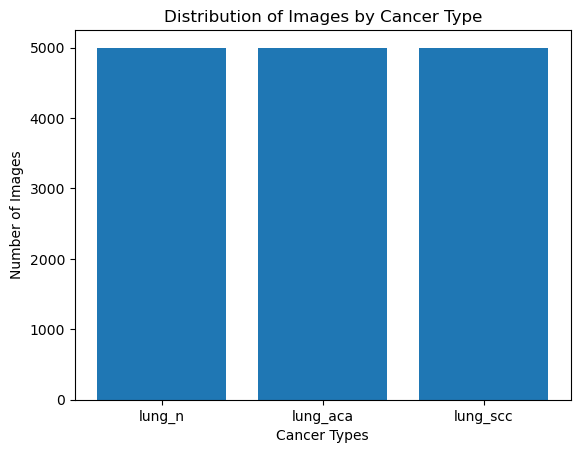

In [81]:
import matplotlib.pyplot as plt
import os

classes = ['lung_n', 'lung_aca', 'lung_scc']
base_dir = 'C:\\Users\\pidik\\Downloads\\lung_image_sets'


class_counts = {}
for class_name in classes:
    class_dir = os.path.join(base_dir, class_name)
    class_counts[class_name] = len(os.listdir(class_dir))


plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel('Cancer Types')
plt.ylabel('Number of Images')
plt.title('Distribution of Images by Cancer Type')
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step


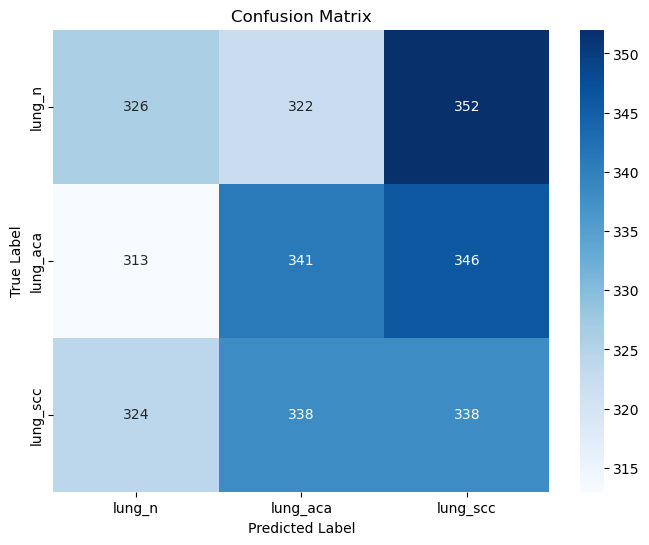

In [82]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict on validation set
y_true = validation_generator.classes
y_pred = model.predict(validation_generator)
y_pred_classes = y_pred.argmax(axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

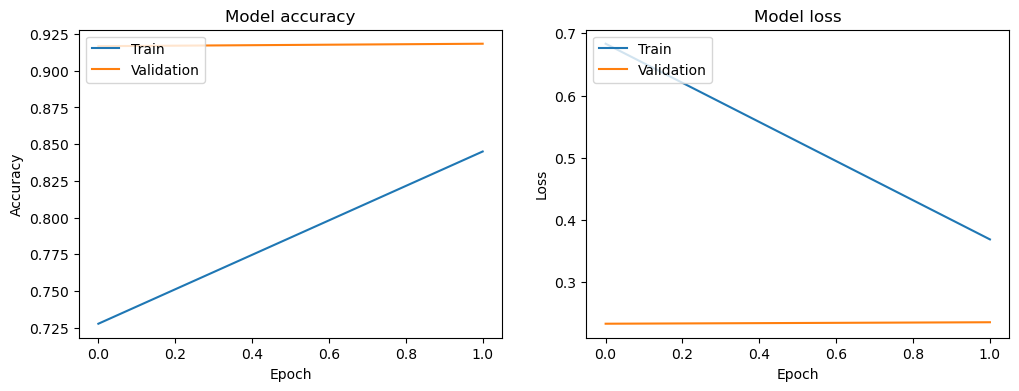

In [83]:
def plot_training_history(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

# After model training:
# history = model.fit(...)
plot_training_history(history)

94/94 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step


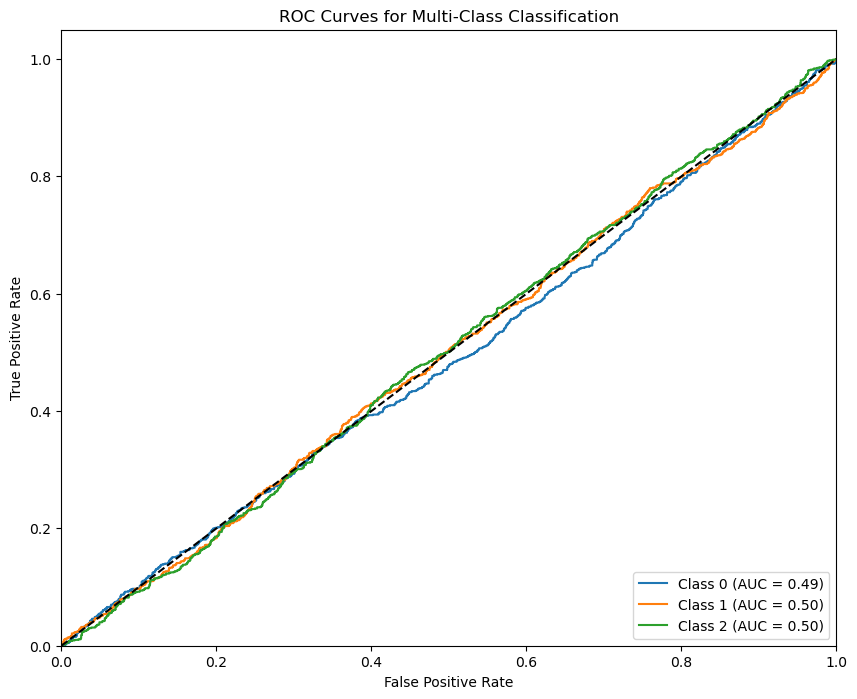

In [84]:
#CNN+RNN

import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Assume `model` is your trained model
# Step 1: Get the predicted probabilities on the validation data
y_pred_prob = model.predict(validation_generator)

# Step 2: Get the true labels
y_true = validation_generator.classes  # Ground truth labels

# Step 3: Binarize the labels for multi-class ROC curve calculation
num_classes = len(validation_generator.class_indices)
y_true_binarized = label_binarize(y_true, classes=range(num_classes))

# Step 4: Plot ROC curve for each class
fpr = dict()  # False Positive Rate
tpr = dict()  # True Positive Rate
roc_auc = dict()  # Area Under the Curve

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 5: Plot the ROC curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Random prediction line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class Classification')
plt.legend(loc='lower right')
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 343s 4s/step


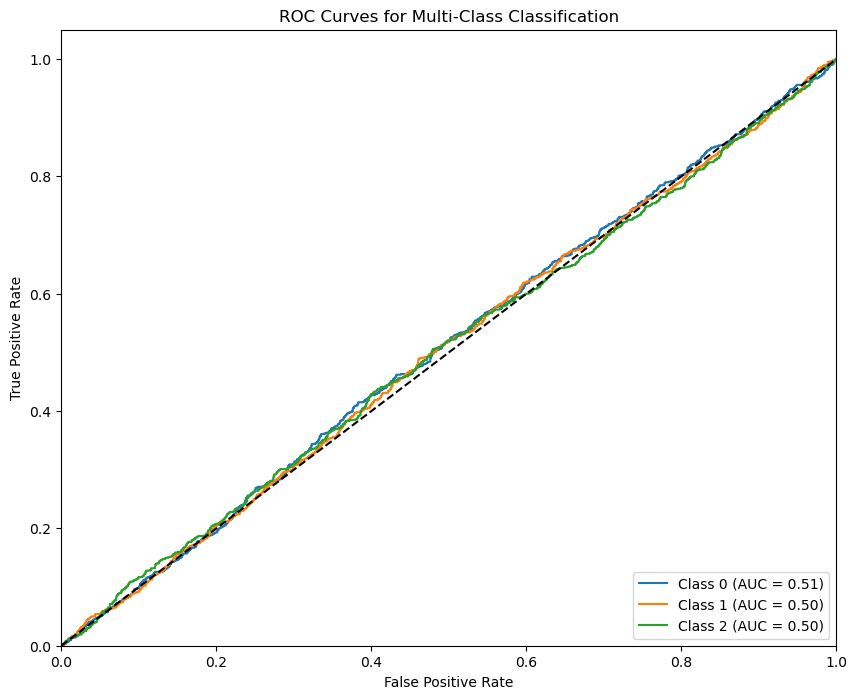

In [85]:
#DenseNet

import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Assume `model` is your trained model
# Step 1: Get the predicted probabilities on the validation data
y_pred_prob = densenet_model.predict(validation_generator)

# Step 2: Get the true labels
y_true = validation_generator.classes  # Ground truth labels

# Step 3: Binarize the labels for multi-class ROC curve calculation
num_classes = len(validation_generator.class_indices)
y_true_binarized = label_binarize(y_true, classes=range(num_classes))

# Step 4: Plot ROC curve for each class
fpr = dict()  # False Positive Rate
tpr = dict()  # True Positive Rate
roc_auc = dict()  # Area Under the Curve

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 5: Plot the ROC curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Random prediction line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class Classification')
plt.legend(loc='lower right')
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 925s 9s/step
NasNet


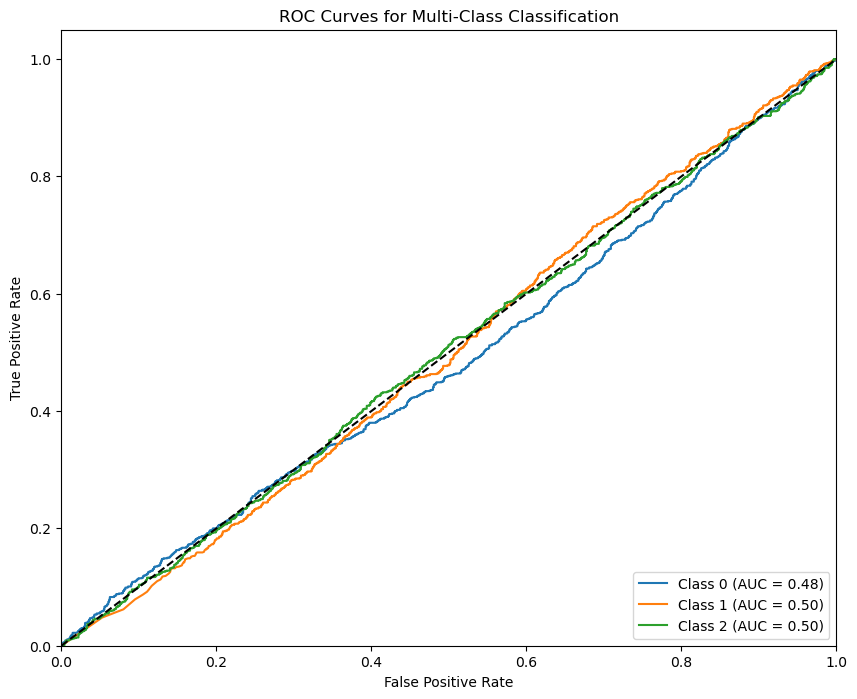

In [86]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Assume `model` is your trained model
# Step 1: Get the predicted probabilities on the validation data
y_pred_prob = nasnet_model.predict(validation_generator)

# Step 2: Get the true labels
y_true = validation_generator.classes  # Ground truth labels

# Step 3: Binarize the labels for multi-class ROC curve calculation
num_classes = len(validation_generator.class_indices)
y_true_binarized = label_binarize(y_true, classes=range(num_classes))

# Step 4: Plot ROC curve for each class
fpr = dict()  # False Positive Rate
tpr = dict()  # True Positive Rate
roc_auc = dict()  # Area Under the Curve

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 5: Plot the ROC curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

print("NasNet")
plt.plot([0, 1], [0, 1], 'k--')  # Random prediction line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class Classification')
plt.legend(loc='lower right')
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 360s 4s/step
Xception


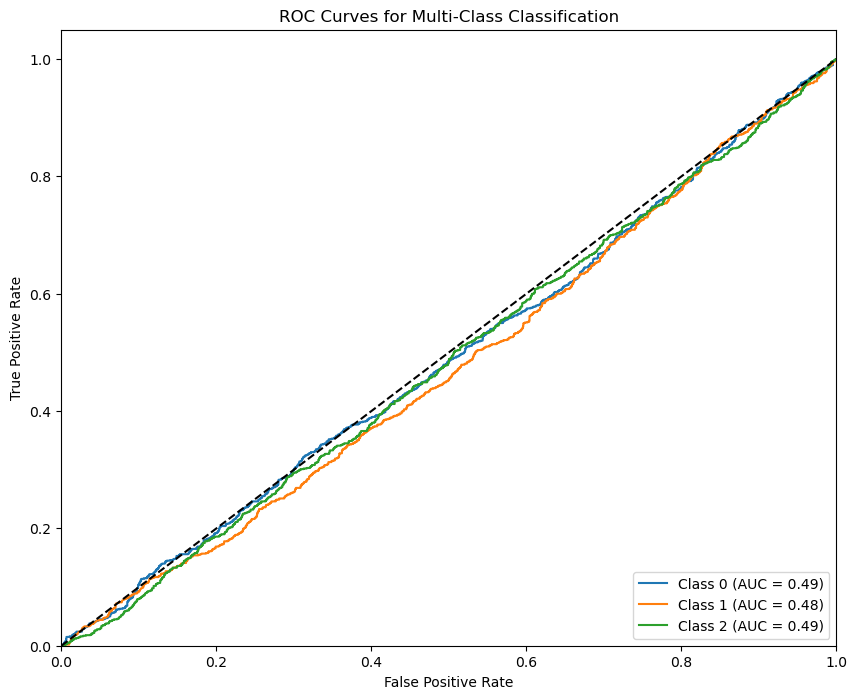

In [88]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Assume `model` is your trained model
# Step 1: Get the predicted probabilities on the validation data
y_pred_prob = xception_model.predict(validation_generator)

# Step 2: Get the true labels
y_true = validation_generator.classes  # Ground truth labels

# Step 3: Binarize the labels for multi-class ROC curve calculation
num_classes = len(validation_generator.class_indices)
y_true_binarized = label_binarize(y_true, classes=range(num_classes))

# Step 4: Plot ROC curve for each class
fpr = dict()  # False Positive Rate
tpr = dict()  # True Positive Rate
roc_auc = dict()  # Area Under the Curve

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 5: Plot the ROC curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

print("Xception")
plt.plot([0, 1], [0, 1], 'k--')  # Random prediction line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class Classification')
plt.legend(loc='lower right')
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step
Inception


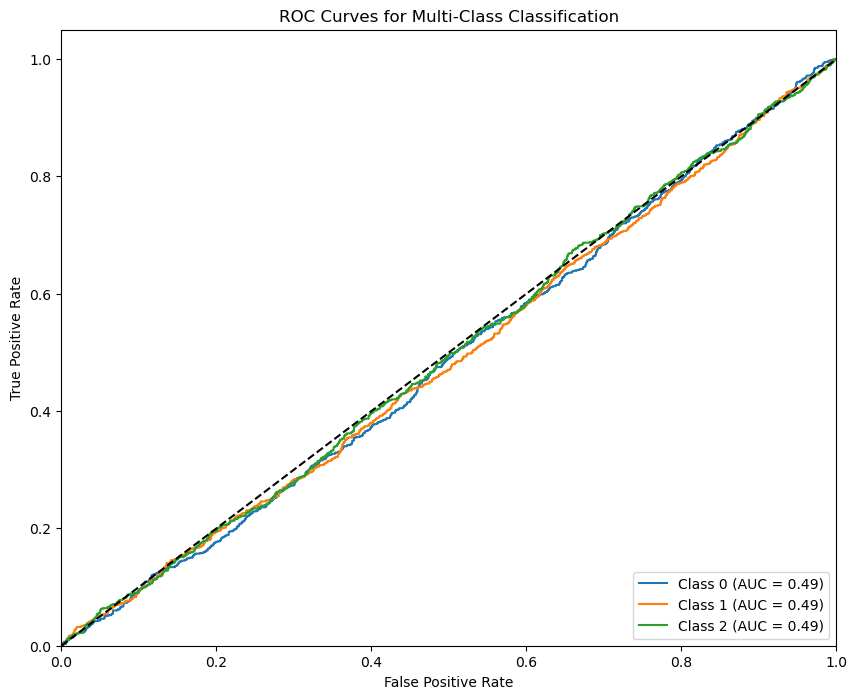

In [89]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Assume `model` is your trained model
# Step 1: Get the predicted probabilities on the validation data
y_pred_prob = inception_model.predict(validation_generator)

# Step 2: Get the true labels
y_true = validation_generator.classes  # Ground truth labels

# Step 3: Binarize the labels for multi-class ROC curve calculation
num_classes = len(validation_generator.class_indices)
y_true_binarized = label_binarize(y_true, classes=range(num_classes))

# Step 4: Plot ROC curve for each class
fpr = dict()  # False Positive Rate
tpr = dict()  # True Positive Rate
roc_auc = dict()  # Area Under the Curve

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 5: Plot the ROC curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

print("Inception")
plt.plot([0, 1], [0, 1], 'k--')  # Random prediction line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class Classification')
plt.legend(loc='lower right')
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 1187s 13s/step
ResNet+VGG16


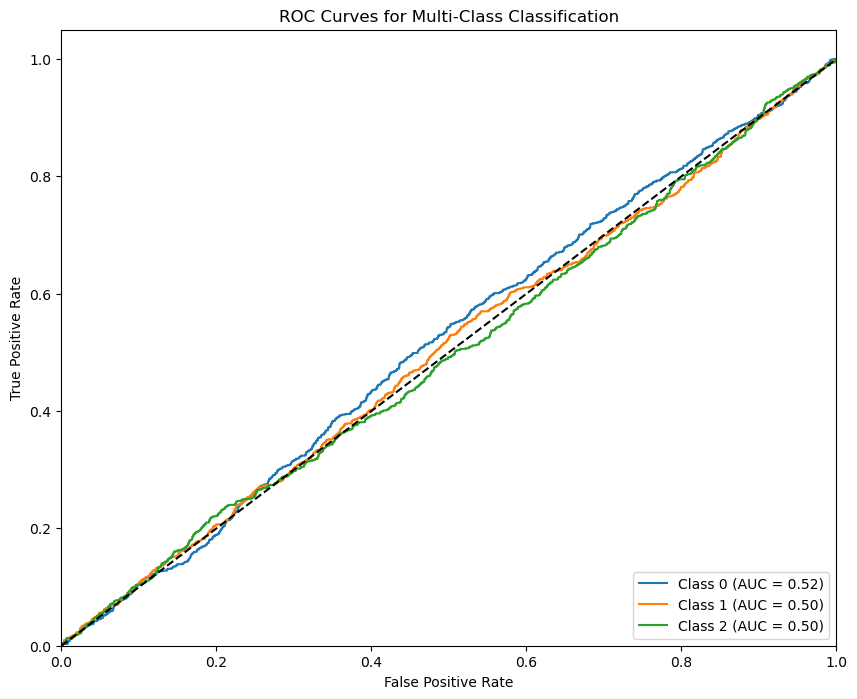

In [90]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Assume `model` is your trained model
# Step 1: Get the predicted probabilities on the validation data
y_pred_prob = combined_model.predict(validation_generator)

# Step 2: Get the true labels
y_true = validation_generator.classes  # Ground truth labels

# Step 3: Binarize the labels for multi-class ROC curve calculation
num_classes = len(validation_generator.class_indices)
y_true_binarized = label_binarize(y_true, classes=range(num_classes))

# Step 4: Plot ROC curve for each class
fpr = dict()  # False Positive Rate
tpr = dict()  # True Positive Rate
roc_auc = dict()  # Area Under the Curve

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 5: Plot the ROC curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

print("ResNet+VGG16")
plt.plot([0, 1], [0, 1], 'k--')  # Random prediction line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-Class Classification')
plt.legend(loc='lower right')
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step


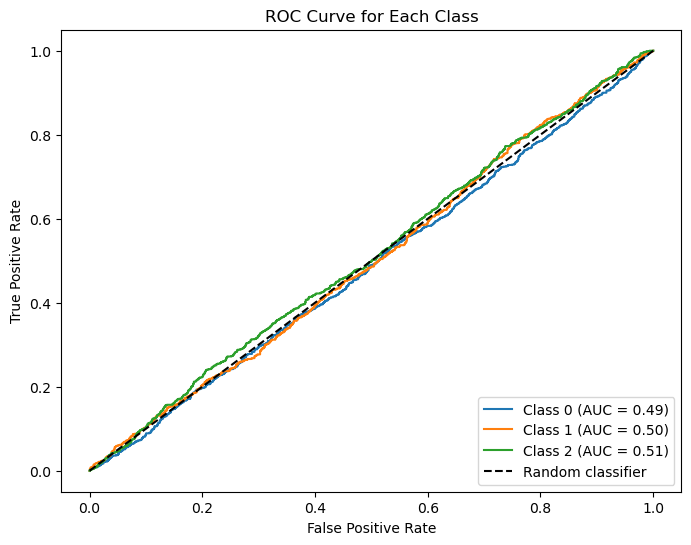

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Generate test predictions and ground truth labels
y_pred_prob = model.predict(test_generator)  # Get predicted probabilities
y_test = test_generator.classes  # True labels

# 2. Binarize the labels for multi-class ROC computation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # Adjust according to the number of classes

# 3. Calculate ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):  # Assuming three classes
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot the ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot random classifier line
plt.plot([0, 1], [0, 1], 'k--', label="Random classifier")

# Add labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend(loc='lower right')
plt.show()